# Task 3: Convolutional Autoencoder for Fabric Defect Detection

**Strategy:** Train an autoencoder on defect-free images only. At inference time, high reconstruction error = anomaly (defect detected).

**Key improvements over v2:**
1. Deeper encoder/decoder with residual blocks
2. Multi-scale patch scoring (128px + 64px patches)
3. Combined MSE+SSIM+Edge loss with progressive scheduling
4. Rich anomaly feature extraction (28 features per image)
5. SVM + LR + Gradient Boosting ensemble classifier
6. Proper threshold optimisation using Youden's J on held-out OOF data
7. Test-Time Augmentation (TTA)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATA_ROOT = "/content/drive/MyDrive/neural_new"
print(os.listdir(DATA_ROOT))

['Test', 'Train']


In [3]:
!pip install -q torch torchvision --upgrade 2>/dev/null
import os, random, json, math, csv, copy
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

In [4]:
def list_files(path):
    all_files = []
    if os.path.exists(path):
        for root, _, files in os.walk(path):
            for f in files:
                all_files.append(os.path.join(root, f))
    return sorted(all_files)

_all_defect_free = list_files(os.path.join(DATA_ROOT, "Train/defect_free"))
random.seed(SEED)
random.shuffle(_all_defect_free)

n_val = max(15, int(0.20 * len(_all_defect_free)))
val_normal_files   = _all_defect_free[:n_val]
train_normal_files = _all_defect_free[n_val:]

defective_files = list_files(os.path.join(DATA_ROOT, "Train/defective"))
test_files = list_files(os.path.join(DATA_ROOT, "Test"))

print(f"Found {len(train_normal_files)} AE-training (defect-free) files.")
print(f"Found {len(val_normal_files)} held-out (defect-free) files for calibration.")
print(f"Found {len(defective_files)} defective files.")
print(f"Found {len(test_files)} test files.")

Found 80 AE-training (defect-free) files.
Found 19 held-out (defect-free) files for calibration.
Found 74 defective files.
Found 74 test files.


In [5]:
PATCH      = 128
PATCH_S    = 64
TRAIN_STRIDE   = 32
INFER_STRIDE   = 16
INFER_STRIDE_S = 12


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(ch, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(ch, affine=True),
        )
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(x + self.block(x))


class ImprovedConvAE(nn.Module):
    def __init__(self, base=32, latent=24):
        super().__init__()

        def enc_block(i, o, norm=True):
            layers = [nn.Conv2d(i, o, 4, 2, 1, bias=not norm)]
            if norm:
                layers.append(nn.InstanceNorm2d(o, affine=True))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        def dec_block(i, o):
            return nn.Sequential(
                nn.ConvTranspose2d(i, o, 4, 2, 1, bias=False),
                nn.InstanceNorm2d(o, affine=True),
                nn.ReLU(inplace=True),
            )

        # Encoder: 128->64->32->16->8->4->2
        self.enc = nn.Sequential(
            enc_block(1,      base,   norm=False),
            enc_block(base,   base*2),
            enc_block(base*2, base*4),
            enc_block(base*4, base*8),
            enc_block(base*8, base*8),
            enc_block(base*8, latent),
        )

        # Decoder: 2->4->8->16->32->64->128
        self.dec = nn.Sequential(
            dec_block(latent,  base*8),
            ResBlock(base*8),
            dec_block(base*8,  base*8),
            ResBlock(base*8),
            dec_block(base*8,  base*4),
            ResBlock(base*4),
            dec_block(base*4,  base*2),
            dec_block(base*2,  base),
            nn.ConvTranspose2d(base, 1, 4, 2, 1),
            nn.Sigmoid(),
        )

        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, a=0.2, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.dec(self.enc(x))

    def encode(self, x):
        return self.enc(x)


model = ImprovedConvAE().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

with torch.no_grad():
    dummy = torch.zeros(2, 1, PATCH, PATCH).to(DEVICE)
    out = model(dummy)
    print(f"Input shape: {dummy.shape}, Output shape: {out.shape}")
    z = model.encode(dummy)
    print(f"Bottleneck shape: {z.shape}")

Model parameters: 6,330,769
Input shape: torch.Size([2, 1, 128, 128]), Output shape: torch.Size([2, 1, 128, 128])
Bottleneck shape: torch.Size([2, 24, 2, 2])


In [6]:
def load_gray(path):
    im = Image.open(path).convert("L")
    return np.asarray(im, dtype=np.float32) / 255.0


class PatchDataset(Dataset):
    def __init__(self, files, patch=PATCH, stride=TRAIN_STRIDE, augment=True):
        self.augment = augment
        self.patch = patch
        self.images = [load_gray(f) for f in files]
        self.coords = []
        for i, im in enumerate(self.images):
            w = im.shape[1]
            xs = list(range(0, w - patch + 1, stride))
            if xs and xs[-1] != w - patch:
                xs.append(w - patch)
            for x0 in xs:
                self.coords.append((i, x0))

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        i, x0 = self.coords[idx]
        patch = self.images[i][:, x0:x0 + self.patch].copy()

        if self.augment:
            if random.random() < 0.5:
                patch = patch[:, ::-1].copy()
            if random.random() < 0.5:
                patch = patch[::-1, :].copy()
            if random.random() < 0.4:
                gamma = random.uniform(0.7, 1.4)
                patch = np.clip(patch ** gamma, 0, 1)
            if random.random() < 0.4:
                patch = np.clip(patch * random.uniform(0.85, 1.15) + random.uniform(-0.07, 0.07), 0, 1)
            noise_std = random.uniform(0.01, 0.05)
            noisy = np.clip(patch + np.random.normal(0, noise_std, patch.shape), 0, 1).astype(np.float32)
            if random.random() < 0.3:
                mh = random.randint(8, self.patch // 4)
                mw = random.randint(8, self.patch // 4)
                r0 = random.randint(0, self.patch - mh)
                c0 = random.randint(0, self.patch - mw)
                noisy[r0:r0+mh, c0:c0+mw] = 0.5
        else:
            noisy = patch

        clean_t = torch.from_numpy(patch.astype(np.float32)).unsqueeze(0)
        noisy_t = torch.from_numpy(noisy.astype(np.float32)).unsqueeze(0)
        return noisy_t, clean_t


train_ds = PatchDataset(train_normal_files, stride=TRAIN_STRIDE, augment=True)
print(f"Training patches: {len(train_ds)} (stride={TRAIN_STRIDE})")

Training patches: 10000 (stride=32)


In [7]:
def gaussian_kernel(window=11, sigma=1.5):
    coords = torch.arange(window).float() - window // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel = g[:, None] @ g[None, :]
    return kernel.unsqueeze(0).unsqueeze(0)

_ssim_kernel = gaussian_kernel(11).to(DEVICE)

_sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32
                         ).unsqueeze(0).unsqueeze(0).to(DEVICE) / 4.0
_sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32
                         ).unsqueeze(0).unsqueeze(0).to(DEVICE) / 4.0


def ssim_loss(img1, img2):
    pad = 5
    mu1 = F.conv2d(img1, _ssim_kernel, padding=pad)
    mu2 = F.conv2d(img2, _ssim_kernel, padding=pad)
    mu1_sq, mu2_sq, mu1mu2 = mu1*mu1, mu2*mu2, mu1*mu2
    s1  = F.conv2d(img1*img1, _ssim_kernel, padding=pad) - mu1_sq
    s2  = F.conv2d(img2*img2, _ssim_kernel, padding=pad) - mu2_sq
    s12 = F.conv2d(img1*img2, _ssim_kernel, padding=pad) - mu1mu2
    C1, C2 = 0.01**2, 0.03**2
    ssim_map = ((2*mu1mu2+C1)*(2*s12+C2)) / ((mu1_sq+mu2_sq+C1)*(s1+s2+C2))
    return 1.0 - ssim_map.mean()


def edge_loss(pred, target):
    ex_p = F.conv2d(pred,   _sobel_x, padding=1)
    ex_t = F.conv2d(target, _sobel_x, padding=1)
    ey_p = F.conv2d(pred,   _sobel_y, padding=1)
    ey_t = F.conv2d(target, _sobel_y, padding=1)
    mag_p = torch.sqrt(ex_p**2 + ey_p**2 + 1e-8)
    mag_t = torch.sqrt(ex_t**2 + ey_t**2 + 1e-8)
    return F.l1_loss(mag_p, mag_t)


def combined_loss(pred, target, alpha=0.6, beta=0.1):
    sl  = ssim_loss(pred, target)
    mse = F.mse_loss(pred, target)
    el  = edge_loss(pred, target)
    loss = alpha * sl + (1 - alpha - beta) * mse + beta * el
    return loss, mse.item(), (1 - sl).item()

epoch   0  loss=0.2718  mse=0.03832  ssim=0.3873  lr=3.00e-04
epoch  10  loss=0.0760  mse=0.00496  ssim=0.8318  lr=2.66e-04
epoch  20  loss=0.0657  mse=0.00277  ssim=0.8597  lr=1.88e-04
epoch  30  loss=0.0630  mse=0.00205  ssim=0.8706  lr=9.55e-05
epoch  40  loss=0.0631  mse=0.00180  ssim=0.8752  lr=2.43e-05
epoch  50  loss=0.0755  mse=0.00298  ssim=0.8569  lr=3.00e-04
epoch  60  loss=0.0680  mse=0.00182  ssim=0.8754  lr=2.66e-04
epoch  70  loss=0.0676  mse=0.00163  ssim=0.8804  lr=1.88e-04
epoch  80  loss=0.0677  mse=0.00148  ssim=0.8843  lr=9.55e-05
epoch  90  loss=0.0685  mse=0.00139  ssim=0.8867  lr=2.43e-05
epoch 100  loss=0.0816  mse=0.00227  ssim=0.8695  lr=3.00e-04
epoch 110  loss=0.0745  mse=0.00153  ssim=0.8843  lr=2.66e-04
epoch 120  loss=0.0749  mse=0.00143  ssim=0.8872  lr=1.88e-04
epoch 130  loss=0.0753  mse=0.00131  ssim=0.8898  lr=9.55e-05
epoch 140  loss=0.0762  mse=0.00125  ssim=0.8917  lr=2.43e-05
epoch 149  loss=0.0778  mse=0.00124  ssim=0.8922  lr=3.00e-04

Loaded 

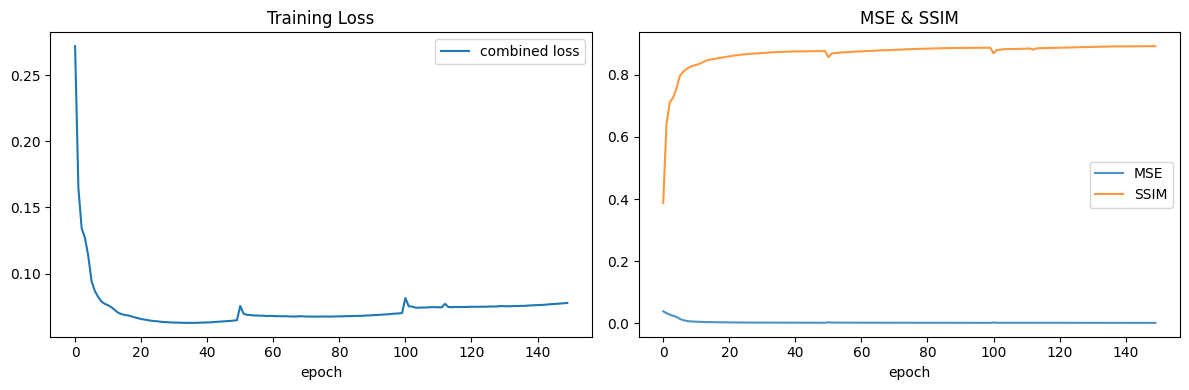

In [8]:
EPOCHS      = 150
BATCH_SIZE  = 32
LR          = 3e-4

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, drop_last=True, pin_memory=True)

opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50, T_mult=1, eta_min=1e-6)

history, best_loss = [], float('inf')

for ep in range(EPOCHS):
    model.train()
    tot_loss = tot_mse = tot_ssim = 0.0
    n = 0
    alpha = min(0.7, 0.4 + 0.3 * ep / EPOCHS)

    for noisy, clean in train_dl:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
        out = model(noisy)
        loss, mse_v, ssim_v = combined_loss(out, clean, alpha=alpha)
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        bs = noisy.size(0)
        tot_loss += loss.item()*bs
        tot_mse  += mse_v*bs
        tot_ssim += ssim_v*bs
        n += bs

    sched.step()
    ep_loss = tot_loss / n
    history.append((ep_loss, tot_mse/n, tot_ssim/n))

    if ep_loss < best_loss:
        best_loss = ep_loss
        torch.save(model.state_dict(), 'fabric_ae_best.pth')

    if ep % 10 == 0 or ep == EPOCHS - 1:
        lr_now = opt.param_groups[0]['lr']
        print(f"epoch {ep:3d}  loss={ep_loss:.4f}  mse={tot_mse/n:.5f}"
              f"  ssim={tot_ssim/n:.4f}  lr={lr_now:.2e}")

model.load_state_dict(torch.load('fabric_ae_best.pth'))
print(f"\nLoaded best model (loss={best_loss:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot([h[0] for h in history], label='combined loss')
ax1.set_title('Training Loss'); ax1.set_xlabel('epoch'); ax1.legend()
ax2.plot([h[1] for h in history], label='MSE', alpha=0.8)
ax2.plot([h[2] for h in history], label='SSIM', alpha=0.8)
ax2.set_title('MSE & SSIM'); ax2.set_xlabel('epoch'); ax2.legend()
plt.tight_layout(); plt.show()

In [9]:
@torch.no_grad()
def score_image(m, path, patch=PATCH, stride=INFER_STRIDE,
                batch_size=64, tta=True):
    m.eval()
    im = load_gray(path)
    h, w = im.shape

    xs = list(range(0, w - patch + 1, stride))
    if xs and xs[-1] != w - patch:
        xs.append(w - patch)

    patches = np.stack([im[:h, x0:x0+patch] for x0 in xs], axis=0)
    t = torch.from_numpy(patches).float().unsqueeze(1).to(DEVICE)

    def batched_error(inp):
        errs = []
        for i in range(0, inp.size(0), batch_size):
            chunk = inp[i:i+batch_size]
            rec   = m(chunk)
            e = F.mse_loss(rec, chunk, reduction='none').mean(dim=[1,2,3])
            errs.append(e.cpu().numpy())
        return np.concatenate(errs)

    errs = batched_error(t)

    if tta:
        errs_hflip = batched_error(t.flip(-1))
        errs_vflip = batched_error(t.flip(-2))
        errs = (errs + errs_hflip + errs_vflip) / 3.0

    k = max(1, int(np.ceil(0.20 * len(errs))))
    scalar_score = float(np.sort(errs)[-k:].mean())
    return scalar_score, errs, xs


@torch.no_grad()
def score_image_small(m, path, patch=PATCH_S, stride=INFER_STRIDE_S,
                      batch_size=128, tta=True):
    m.eval()
    im = load_gray(path)
    h, w = im.shape

    xs = list(range(0, w - patch + 1, stride))
    if xs and xs[-1] != w - patch:
        xs.append(w - patch)

    patches_np = np.stack([im[:h, x0:x0+patch] for x0 in xs], axis=0)
    t_small = torch.from_numpy(patches_np).float().unsqueeze(1).to(DEVICE)
    t = F.interpolate(t_small, size=(PATCH, PATCH), mode='bilinear', align_corners=False)

    def batched_error(inp):
        errs = []
        for i in range(0, inp.size(0), batch_size):
            chunk = inp[i:i+batch_size]
            rec   = m(chunk)
            e = F.mse_loss(rec, chunk, reduction='none').mean(dim=[1,2,3])
            errs.append(e.cpu().numpy())
        return np.concatenate(errs)

    errs = batched_error(t)

    if tta:
        errs_hflip = batched_error(t.flip(-1))
        errs_vflip = batched_error(t.flip(-2))
        errs = (errs + errs_hflip + errs_vflip) / 3.0

    k = max(1, int(np.ceil(0.20 * len(errs))))
    scalar_score = float(np.sort(errs)[-k:].mean())
    return scalar_score, errs, xs


print("Testing scorer on first defect-free file...")
s, errs, xs = score_image(model, val_normal_files[0])
print(f"  Score: {s:.4f}, patches: {len(errs)}, mean err: {errs.mean():.4f}")

Testing scorer on first defect-free file...
  Score: 0.0051, patches: 249, mean err: 0.0022


In [10]:
def robust_stats(errs):
    med = np.median(errs)
    mad = np.median(np.abs(errs - med)) + 1e-9
    z = (errs - med) / mad
    z_sorted = np.sort(z)

    def topk_mean(frac):
        k = max(1, int(np.ceil(frac * len(z_sorted))))
        return float(z_sorted[-k:].mean())

    return [
        topk_mean(0.02), topk_mean(0.05), topk_mean(0.10),
        topk_mean(0.20), topk_mean(0.35),
        float(z_sorted[-1]),       # single worst patch
        float(z.mean()), float(z.std()),
        float((z > 2.0).mean()),   # fraction beyond 2-sigma
        float((z > 3.0).mean()),   # fraction beyond 3-sigma
        float(z_sorted[-1] - z_sorted[0]),  # range
        float(np.percentile(z, 75) - np.percentile(z, 25)),  # IQR
    ]


def spatial_concentration(errs, xs, n_bins=8):
    if len(errs) == 0:
        return 0.0
    xs_arr = np.array(xs, dtype=np.float32)
    xs_norm = (xs_arr - xs_arr.min()) / (xs_arr.max() - xs_arr.min() + 1e-8)
    weights = errs / (errs.mean() + 1e-8)
    bin_idx = np.clip((xs_norm * n_bins).astype(int), 0, n_bins - 1)
    bin_sums = np.bincount(bin_idx, weights=weights, minlength=n_bins)
    return float(bin_sums.max() / (bin_sums.sum() + 1e-8))


def extract_features(m, path):
    _, errs_l, xs_l = score_image(m, path, tta=True)
    _, errs_s, xs_s = score_image_small(m, path, tta=True)

    feat = robust_stats(errs_l) + robust_stats(errs_s)

    # Raw scale scores
    k_l = max(1, int(np.ceil(0.10 * len(errs_l))))
    k_s = max(1, int(np.ceil(0.10 * len(errs_s))))
    feat.append(float(np.sort(errs_l)[-k_l:].mean()))
    feat.append(float(np.sort(errs_s)[-k_s:].mean()))

    # Spatial concentration
    feat.append(spatial_concentration(errs_l, xs_l))
    feat.append(spatial_concentration(errs_s, xs_s))

    return np.array(feat, dtype=np.float32)


print("Testing feature extractor...")
f_test = extract_features(model, val_normal_files[0])
print(f"Feature vector length: {len(f_test)}")
print(f"Values: {f_test}")

Testing feature extractor...
Feature vector length: 28
Values: [6.9866554e+01 4.0447197e+01 2.5842836e+01 1.7932144e+01 1.2799628e+01
 8.1125099e+01 4.1372471e+00 1.1517983e+01 2.8915662e-01 2.8915662e-01
 8.3108749e+01 1.0833288e+01 7.2135666e+01 7.1931061e+01 7.1859444e+01
 7.1823631e+01 5.6538555e+01 7.4222618e+01 1.9385710e+01 3.2125271e+01
 2.8486648e-01 2.8189912e-01 7.6758087e+01 7.2613029e+01 6.7232046e-03
 1.3321775e-01 2.5682360e-01 3.7209815e-01]


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

calib_files  = val_normal_files + defective_files
calib_labels = np.array([0]*len(val_normal_files) + [1]*len(defective_files))

print(f"Extracting features for {len(calib_files)} calibration images...")
X_calib = []
for i, f in enumerate(calib_files):
    feat = extract_features(model, f)
    X_calib.append(feat)
    if (i+1) % 20 == 0 or i == len(calib_files)-1:
        print(f"  {i+1}/{len(calib_files)} done")

X_calib = np.stack(X_calib)
y_calib = calib_labels
print(f"Feature matrix: {X_calib.shape}")
print(f"Class distribution: {np.bincount(y_calib)} [defect-free, defective]")

Extracting features for 93 calibration images...
  20/93 done
  40/93 done
  60/93 done
  80/93 done
  93/93 done
Feature matrix: (93, 28)
Class distribution: [19 74] [defect-free, defective]


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_calib)

def cv_balanced_acc(clf, X, y, cv):
    fold_accs = []
    for tr, te in cv.split(X, y):
        c = copy.deepcopy(clf)
        c.fit(X[tr], y[tr])
        pred = c.predict(X[te])
        fold_accs.append(balanced_accuracy_score(y[te], pred))
    return fold_accs

lr_clf = LogisticRegression(class_weight='balanced', C=0.5, max_iter=2000,
                             solver='lbfgs', random_state=SEED)
svm_clf = CalibratedClassifierCV(
    SVC(kernel='rbf', C=2.0, gamma='scale', class_weight='balanced',
        probability=False, random_state=SEED), cv=3)
gb_clf = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=SEED)

ensemble = VotingClassifier(
    estimators=[('lr', lr_clf), ('svm', svm_clf), ('gb', gb_clf)],
    voting='soft')

print("Cross-validating classifiers...")
lr_accs  = cv_balanced_acc(lr_clf,  X_scaled, y_calib, skf)
svm_accs = cv_balanced_acc(svm_clf, X_scaled, y_calib, skf)
gb_accs  = cv_balanced_acc(gb_clf,  X_scaled, y_calib, skf)
ens_accs = cv_balanced_acc(ensemble, X_scaled, y_calib, skf)

print(f"Logistic Regression  CV bacc: {np.mean(lr_accs):.4f} {[f'{a:.3f}' for a in lr_accs]}")
print(f"SVM (RBF)            CV bacc: {np.mean(svm_accs):.4f} {[f'{a:.3f}' for a in svm_accs]}")
print(f"Gradient Boosting    CV bacc: {np.mean(gb_accs):.4f} {[f'{a:.3f}' for a in gb_accs]}")
print(f"Ensemble (soft vote) CV bacc: {np.mean(ens_accs):.4f} {[f'{a:.3f}' for a in ens_accs]}")

Cross-validating classifiers...
Logistic Regression  CV bacc: 0.6814 ['0.767', '0.650', '0.833', '0.857', '0.300']
SVM (RBF)            CV bacc: 0.5000 ['0.500', '0.500', '0.500', '0.500', '0.500']
Gradient Boosting    CV bacc: 0.7224 ['0.717', '0.717', '0.750', '0.929', '0.500']
Ensemble (soft vote) CV bacc: 0.6857 ['0.750', '0.625', '0.625', '0.929', '0.500']


Best classifier: GB (CV balanced acc = 0.7224)

--- Full calibration pool (train-set, informational) ---
[[19  0]
 [ 0 74]]
Balanced acc: 1.0000
ROC-AUC     : 1.0000
              precision    recall  f1-score   support

 defect-free       1.00      1.00      1.00        19
   defective       1.00      1.00      1.00        74

    accuracy                           1.00        93
   macro avg       1.00      1.00      1.00        93
weighted avg       1.00      1.00      1.00        93



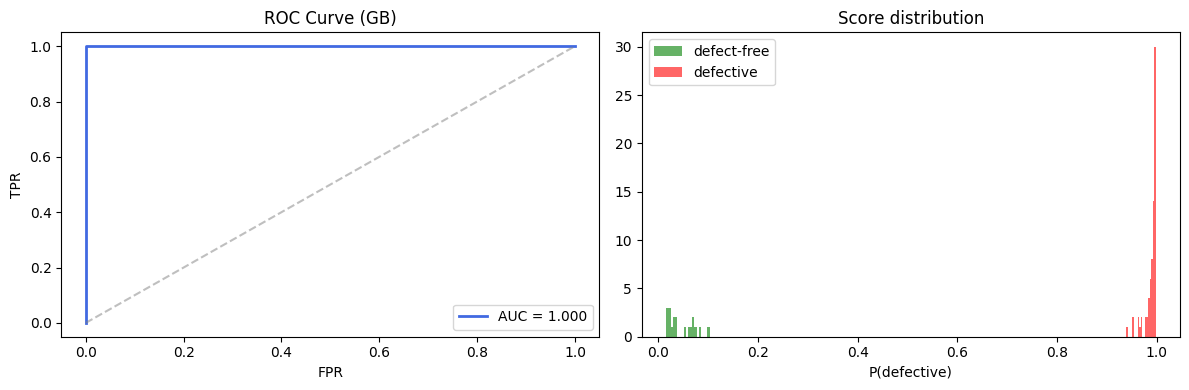

In [13]:
results = {
    'LR':       (np.mean(lr_accs),  lr_clf),
    'SVM':      (np.mean(svm_accs), svm_clf),
    'GB':       (np.mean(gb_accs),  gb_clf),
    'Ensemble': (np.mean(ens_accs), ensemble),
}
best_name, (best_cv_acc, best_clf) = max(results.items(), key=lambda x: x[1][0])
print(f"Best classifier: {best_name} (CV balanced acc = {best_cv_acc:.4f})")

final_scaler = StandardScaler().fit(X_calib)
X_final = final_scaler.transform(X_calib)
best_clf.fit(X_final, y_calib)

pred_full = best_clf.predict(X_final)
pred_prob = best_clf.predict_proba(X_final)[:, 1]

print("\n--- Full calibration pool (train-set, informational) ---")
print(confusion_matrix(y_calib, pred_full))
print(f"Balanced acc: {balanced_accuracy_score(y_calib, pred_full):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_calib, pred_prob):.4f}")
print(classification_report(y_calib, pred_full, target_names=['defect-free','defective']))

fpr, tpr, _ = roc_curve(y_calib, pred_prob)
roc_auc = auc(fpr, tpr)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', color='royalblue', lw=2)
axes[0].plot([0,1],[0,1], '--', color='gray', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'ROC Curve ({best_name})'); axes[0].legend()
axes[1].hist(pred_prob[y_calib==0], bins=20, alpha=0.6, label='defect-free', color='green')
axes[1].hist(pred_prob[y_calib==1], bins=20, alpha=0.6, label='defective',   color='red')
axes[1].set_xlabel('P(defective)'); axes[1].set_title('Score distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

OOF ROC-AUC           : 0.8378
Optimal threshold (J) : 0.8639
OOF Balanced accuracy : 0.8076

OOF Confusion matrix [rows=true, cols=pred] (0=defect-free, 1=defective):
[[14  5]
 [ 9 65]]

              precision    recall  f1-score   support

 defect-free       0.61      0.74      0.67        19
   defective       0.93      0.88      0.90        74

    accuracy                           0.85        93
   macro avg       0.77      0.81      0.78        93
weighted avg       0.86      0.85      0.85        93



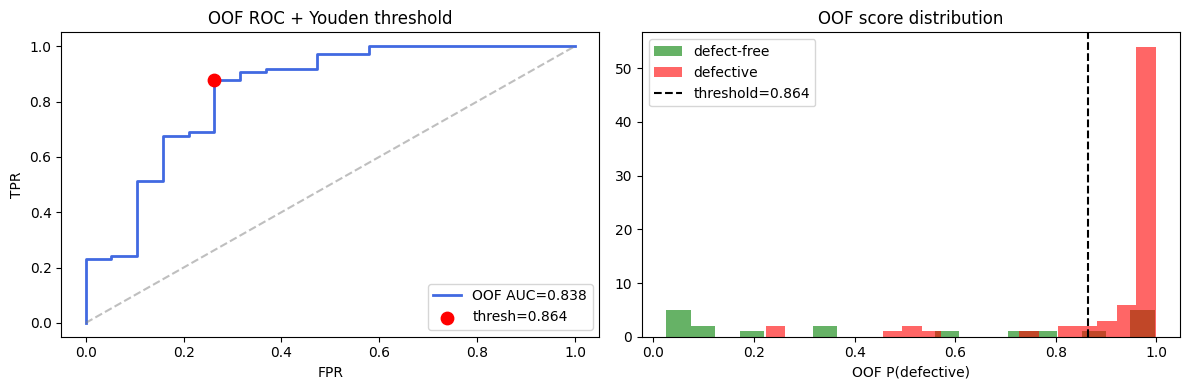

In [14]:
# OOF (Out-of-Fold) predictions for unbiased threshold estimation
oof_probs = np.zeros(len(y_calib))

for tr, te in skf.split(X_calib, y_calib):
    sc = StandardScaler().fit(X_calib[tr])
    Xtr = sc.transform(X_calib[tr])
    Xte = sc.transform(X_calib[te])
    clf_fold = copy.deepcopy(best_clf)
    clf_fold.fit(Xtr, y_calib[tr])
    oof_probs[te] = clf_fold.predict_proba(Xte)[:, 1]

# Youden's J optimal threshold
oof_fpr, oof_tpr, oof_thresholds = roc_curve(y_calib, oof_probs)
youden_j = oof_tpr - oof_fpr
best_threshold_idx = np.argmax(youden_j)
optimal_threshold = float(oof_thresholds[best_threshold_idx])

oof_pred = (oof_probs >= optimal_threshold).astype(int)
oof_bacc = balanced_accuracy_score(y_calib, oof_pred)
oof_auc  = roc_auc_score(y_calib, oof_probs)

print(f"OOF ROC-AUC           : {oof_auc:.4f}")
print(f"Optimal threshold (J) : {optimal_threshold:.4f}")
print(f"OOF Balanced accuracy : {oof_bacc:.4f}")
print()
print("OOF Confusion matrix [rows=true, cols=pred] (0=defect-free, 1=defective):")
print(confusion_matrix(y_calib, oof_pred))
print()
print(classification_report(y_calib, oof_pred, target_names=['defect-free','defective']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(oof_fpr, oof_tpr, label=f'OOF AUC={oof_auc:.3f}', color='royalblue', lw=2)
axes[0].scatter([oof_fpr[best_threshold_idx]], [oof_tpr[best_threshold_idx]],
                color='red', zorder=5, s=80, label=f'thresh={optimal_threshold:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('OOF ROC + Youden threshold'); axes[0].legend()
axes[1].hist(oof_probs[y_calib==0], bins=20, alpha=0.6, label='defect-free', color='green')
axes[1].hist(oof_probs[y_calib==1], bins=20, alpha=0.6, label='defective',   color='red')
axes[1].axvline(optimal_threshold, color='black', linestyle='--',
                label=f'threshold={optimal_threshold:.3f}')
axes[1].set_xlabel('OOF P(defective)'); axes[1].set_title('OOF score distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

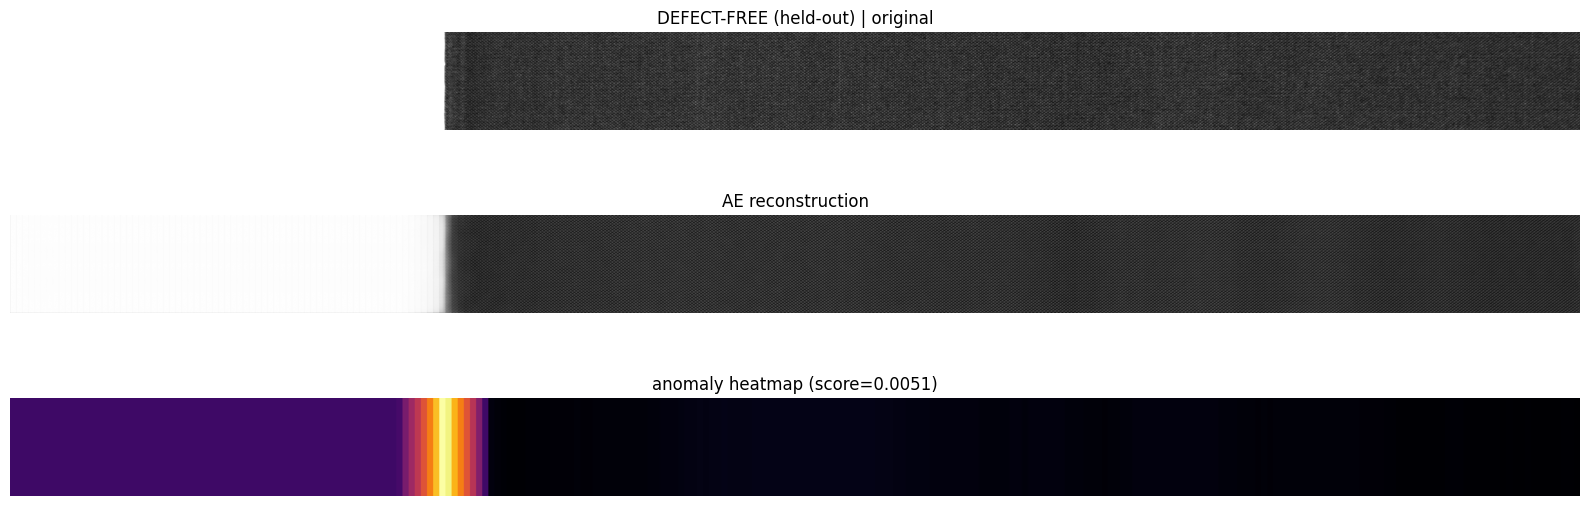

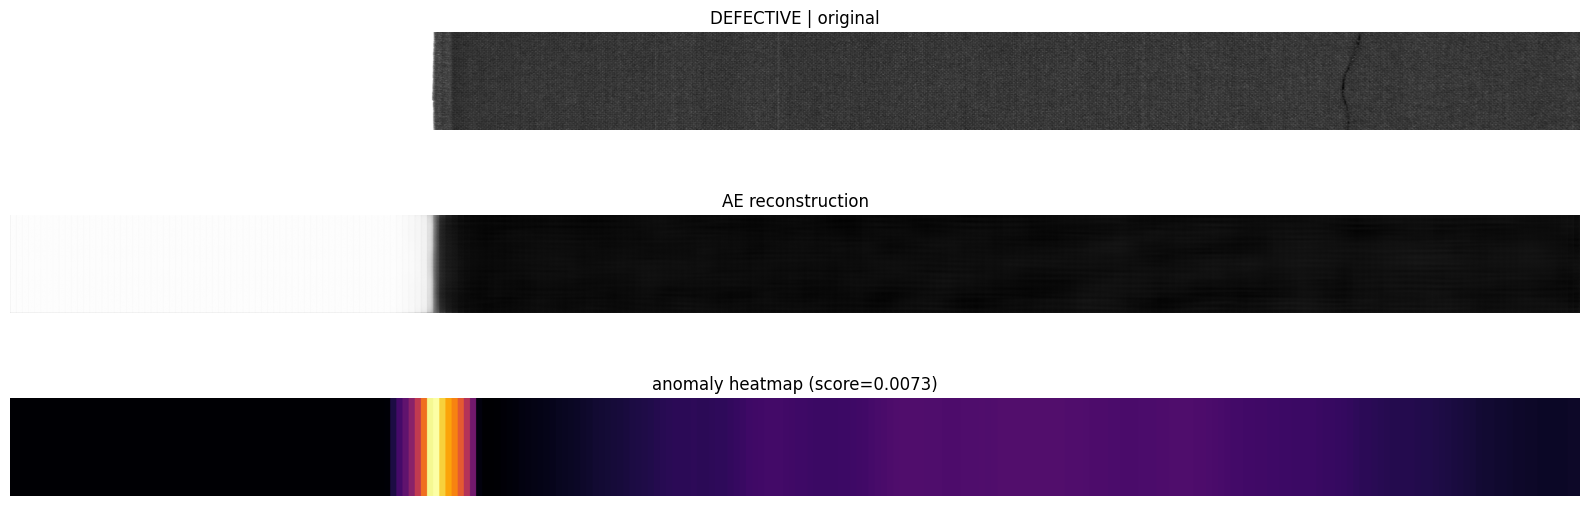

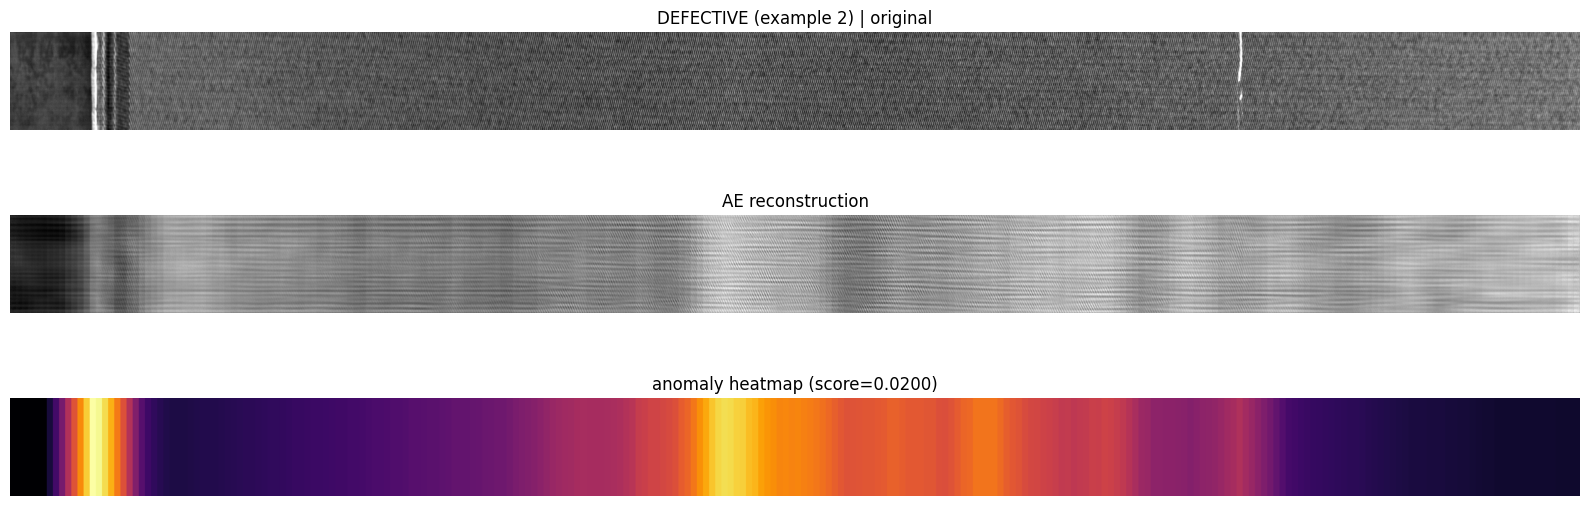

In [15]:
@torch.no_grad()
def show_example(path, title):
    im = load_gray(path)
    h, w = im.shape
    score, errs, xs = score_image(model, path)

    recon  = np.zeros_like(im); weight   = np.zeros_like(im)
    err_full = np.zeros_like(im); wsum   = np.zeros_like(im)

    t = torch.from_numpy(im).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    for e, x0 in zip(errs, xs):
        patch_t = t[:, :, :, x0:x0+PATCH]
        out = model(patch_t).cpu().numpy()[0, 0]
        recon[:,    x0:x0+PATCH] += out
        weight[:,   x0:x0+PATCH] += 1
        err_full[:, x0:x0+PATCH] += e
        wsum[:,     x0:x0+PATCH] += 1

    recon    /= np.maximum(weight, 1)
    err_full /= np.maximum(wsum, 1)

    fig, axes = plt.subplots(3, 1, figsize=(16, 6))
    axes[0].imshow(im,       cmap='gray');    axes[0].set_title(f'{title} | original'); axes[0].axis('off')
    axes[1].imshow(recon,    cmap='gray');    axes[1].set_title('AE reconstruction');   axes[1].axis('off')
    axes[2].imshow(err_full, cmap='inferno'); axes[2].set_title(f'anomaly heatmap (score={score:.4f})'); axes[2].axis('off')
    plt.tight_layout(); plt.show()

show_example(val_normal_files[0], 'DEFECT-FREE (held-out)')
show_example(defective_files[0],  'DEFECTIVE')
show_example(defective_files[10], 'DEFECTIVE (example 2)')

Extracting features for 74 test images...
  20/74 done
  40/74 done
  60/74 done
  74/74 done

Wrote submission.csv: 74 rows
Predicted defective  : 48 (64.9%)
Predicted defect-free: 26 (35.1%)


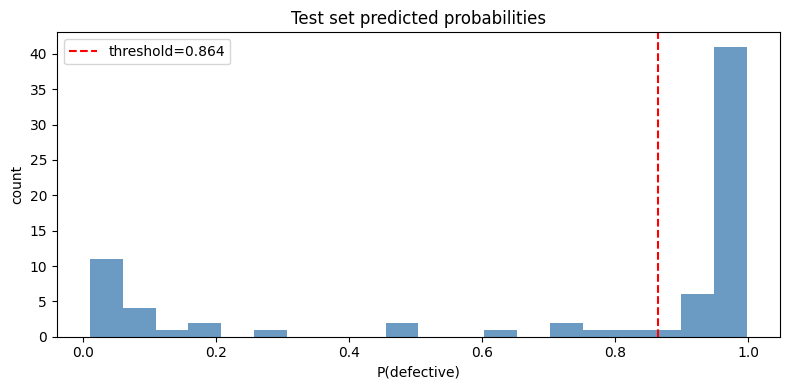

In [16]:
print(f"Extracting features for {len(test_files)} test images...")
X_test = []
for i, f in enumerate(test_files):
    feat = extract_features(model, f)
    X_test.append(feat)
    if (i+1) % 20 == 0 or i == len(test_files)-1:
        print(f"  {i+1}/{len(test_files)} done")

X_test = np.stack(X_test)
X_test_scaled = final_scaler.transform(X_test)

test_probs = best_clf.predict_proba(X_test_scaled)[:, 1]
test_preds = (test_probs >= optimal_threshold).astype(int)

rows = []
for f, pred in zip(test_files, test_preds):
    rows.append((os.path.basename(f), int(pred)))
rows.sort(key=lambda x: x[0])

with open('submission.csv', 'w', newline='') as fh:
    w = csv.writer(fh)
    w.writerow(['ID', 'label'])
    w.writerows(rows)

n_pos = sum(r[1] for r in rows)
print(f"\nWrote submission.csv: {len(rows)} rows")
print(f"Predicted defective  : {n_pos} ({100*n_pos/len(rows):.1f}%)")
print(f"Predicted defect-free: {len(rows)-n_pos} ({100*(len(rows)-n_pos)/len(rows):.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(test_probs, bins=20, color='steelblue', alpha=0.8)
plt.axvline(optimal_threshold, color='red', linestyle='--',
            label=f'threshold={optimal_threshold:.3f}')
plt.xlabel('P(defective)'); plt.ylabel('count')
plt.title('Test set predicted probabilities')
plt.legend(); plt.tight_layout(); plt.show()

In [17]:
meta = {
    'best_classifier': best_name,
    'cv_balanced_acc': float(best_cv_acc),
    'oof_balanced_acc': float(oof_bacc),
    'oof_roc_auc': float(oof_auc),
    'optimal_threshold': float(optimal_threshold),
    'n_test': len(rows),
    'n_predicted_defective': int(n_pos),
    'feature_vector_length': int(X_calib.shape[1]),
    'patch_sizes': [PATCH, PATCH_S],
    'epochs': EPOCHS,
}
with open('run_metadata.json', 'w') as fh:
    json.dump(meta, fh, indent=2)
print('Saved run_metadata.json')
print(json.dumps(meta, indent=2))

Saved run_metadata.json
{
  "best_classifier": "GB",
  "cv_balanced_acc": 0.7223809523809525,
  "oof_balanced_acc": 0.8076102418207681,
  "oof_roc_auc": 0.8378378378378379,
  "optimal_threshold": 0.8639199993011958,
  "n_test": 74,
  "n_predicted_defective": 48,
  "feature_vector_length": 28,
  "patch_sizes": [
    128,
    64
  ],
  "epochs": 150
}
